# Layer 2: Avellaneda-Stoikov Per-Regime Cost Calibration

This notebook calibrates the A&S market microstructure cost model separately for each
HMM regime (Calm, Volatile, Stressed) using Binance trade tick data.

## A&S Cost Model

$$
\text{Cost}(q, \sigma, s, \delta, \gamma) = \sigma \sqrt{\frac{q}{2\delta}} \cdot P + \frac{s}{2} \cdot P + \gamma \frac{q^2}{2\delta} \cdot P
$$

where:
- $q$ = order size (asset units)
- $\sigma$ = annualized volatility
- $s$ = bid-ask spread (price units)
- $\delta$ = market depth (volume per price unit)
- $\gamma$ = risk aversion
- $P$ = current price

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import json

from src.layer2_as.as_calibrate import (
    estimate_spread_from_trades,
    estimate_volatility,
    estimate_depth,
    calibrate_regime,
    compute_cost,
    compute_cost_bps,
    lee_ready_classify_trades,
    GAMMA_DEFAULTS,
    validate_cost_ratios,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

DATA_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
HMM_DIR = MODELS_DIR / 'hmm'
AS_COST_DIR = MODELS_DIR / 'as_cost'
AS_COST_DIR.mkdir(parents=True, exist_ok=True)

REGIME_COLORS = {'Calm': '#2ecc71', 'Volatile': '#f39c12', 'Stressed': '#e74c3c'}
REGIME_ORDER = ['Calm', 'Volatile', 'Stressed']

## 1. Load Data

In [2]:
# Load regime labels from HMM
regime_labels = pd.read_csv(HMM_DIR / 'regime_labels.csv', index_col=0).squeeze("columns")
regime_labels.index = pd.to_datetime(regime_labels.index)
print(f"Regime labels loaded: {len(regime_labels)} records")
print(f"\nRegime distribution:")
print(regime_labels.value_counts())

Regime labels loaded: 8656 records

Regime distribution:
0
Calm        7256
Volatile    1380
Stressed      20
Name: count, dtype: int64


In [3]:
# Load processed trade and price data
trades_df = pd.read_parquet(DATA_DIR / 'trades_processed.parquet')
price_df = pd.read_parquet(DATA_DIR / 'price_features.parquet')

print(f"Trades loaded: {len(trades_df)} records")
print(f"Prices loaded: {len(price_df)} records")
print(f"\nTrades columns: {list(trades_df.columns)}")
print(f"Prices columns: {list(price_df.columns)}")

Trades loaded: 8656 records
Prices loaded: 8656 records

Trades columns: ['timestamp', 'side', 'volume', 'price']
Prices columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'btc_close', 'eth_close', 'btc_return', 'eth_return', 'realized_vol', 'spread_proxy', 'btc_return_lag_1', 'btc_return_lag_3', 'btc_return_lag_6', 'eth_return_lag_1', 'eth_return_lag_3', 'eth_return_lag_6', 'btc_return_for_eth_model', 'eth_return_for_btc_model']


In [4]:
# Check data time range alignment
print(f"Regime labels: {regime_labels.index.min()} to {regime_labels.index.max()}")
print(f"Trades: {trades_df['timestamp'].min()} to {trades_df['timestamp'].max()}")
print(f"Prices: {price_df['timestamp'].min()} to {price_df['timestamp'].max()}")

Regime labels: 2026-03-05 00:00:00 to 2026-04-04 01:15:00
Trades: 2026-03-05 00:00:00 to 2026-04-04 01:15:00
Prices: 2026-03-05 00:00:00 to 2026-04-04 01:15:00


## 2. Apply Lee-Ready Trade Classification

In [5]:
# Apply Lee-Ready tick rule to classify trades as buy/sell initiated
# This is needed for spread estimation
trades_df = lee_ready_classify_trades(trades_df)

print("Trade classification (Lee-Ready tick rule):")
print(trades_df['side'].value_counts())

Trade classification (Lee-Ready tick rule):
side
buy     5723
sell    2933
Name: count, dtype: int64


## 3. Per-Regime Calibration

In [6]:
# Calibrate A&S parameters for each regime
regime_map = {label: idx for idx, label in enumerate(['Calm', 'Volatile', 'Stressed'])}

results = {}
for regime in REGIME_ORDER:
    print(f"\nCalibrating {regime}...")
    params = calibrate_regime(
        trades_df,
        price_df,
        regime,
        regime_map[regime],
        regime_labels,
    )
    if params is not None:
        results[regime] = params

2026-04-04 11:16:35,826 INFO   Calm: 7256 bars matched



Calibrating Calm...


2026-04-04 11:16:35,991 INFO   Calm: spread=33.814963, vol=3.9596, depth=0.02, gamma=0.5


2026-04-04 11:16:35,994 INFO   Volatile: 1380 bars matched



Calibrating Volatile...


2026-04-04 11:16:36,064 INFO   Volatile: spread=33.804082, vol=3.9990, depth=0.02, gamma=1.0


2026-04-04 11:16:36,069 INFO   Stressed: 20 bars matched


2026-04-04 11:16:36,081 INFO   Stressed: spread=40.931540, vol=0.1455, depth=0.04, gamma=2.0



Calibrating Stressed...


In [7]:
# Display calibrated parameters
params_df = pd.DataFrame(results).T
params_df = params_df[['regime', 'n_trades', 'n_price_bars', 'spread', 'volatility', 'depth', 'gamma']]
print("\n=== Calibrated A&S Parameters ===")
print(params_df.to_string())


=== Calibrated A&S Parameters ===
            regime n_trades n_price_bars     spread volatility     depth gamma
Calm          Calm     8656         8656  33.814963   3.959594   0.02136   0.5
Volatile  Volatile     8484         8484  33.804082   3.999049  0.021379   1.0
Stressed  Stressed       20           20   40.93154   0.145459  0.043574   2.0


## 4. Compute A&S Costs for 50 bps Trade

In [8]:
# Compute costs for a 50 bps notional trade
TRADE_SIZE_BPS = 0.0050  # 50 bps
REFERENCE_PRICE = 1.0  # Use normalized price for ratio comparison

cost_summary = []
for regime in REGIME_ORDER:
    if regime in results:
        params = results[regime]
        cost_breakdown = compute_cost(TRADE_SIZE_BPS, params, REFERENCE_PRICE)
        cost_bps = compute_cost_bps(TRADE_SIZE_BPS, params, REFERENCE_PRICE)
        
        cost_summary.append({
            'Regime': regime,
            'Total Cost (bps)': cost_bps,
            'Market Impact (bps)': (cost_breakdown['market_impact'] / REFERENCE_PRICE / TRADE_SIZE_BPS) * 10000,
            'Spread Cost (bps)': (cost_breakdown['spread_cost'] / REFERENCE_PRICE / TRADE_SIZE_BPS) * 10000,
            'Inventory Risk (bps)': (cost_breakdown['inventory_risk'] / REFERENCE_PRICE / TRADE_SIZE_BPS) * 10000,
        })

cost_summary_df = pd.DataFrame(cost_summary).set_index('Regime')
print(f"\n=== A&S Cost Breakdown for {TRADE_SIZE_BPS * 10000:.0f} bps Trade ===")
print(cost_summary_df.round(2).to_string())


=== A&S Cost Breakdown for 50 bps Trade ===
          Total Cost (bps)  Market Impact (bps)  Spread Cost (bps)  Inventory Risk (bps)
Regime                                                                                  
Calm           33823904.70              8356.15        33814963.35                585.20
Volatile       33813686.63              8435.69        33804081.57               1169.37
Stressed       40932902.57               214.92        40931540.18               1147.47


## 5. Validate Cost Ratios

In [9]:
# Validate that Stressed cost is 10-100x Calm cost
validation = validate_cost_ratios(results, TRADE_SIZE_BPS)

print("\n=== Validation Results ===")
print(f"Calm cost: {validation['costs_bps'].get('Calm', 'N/A'):.2f} bps")
print(f"Stressed cost: {validation['costs_bps'].get('Stressed', 'N/A'):.2f} bps")
print(f"Stressed/Calm ratio: {validation['ratios'].get('stressed_to_calm', 'N/A'):.1f}x")
print(f"Volatility ratio: {validation['ratios'].get('volatility', 'N/A'):.1f}x")
print(f"\nValidation: {'PASSED' if validation['passed'] else 'FAILED'}")
print(f"Message: {validation['message']}")

2026-04-04 11:16:36,160 WARNING   Stressed vol fixed to 7.9192 (2x calm vol=3.9596)


2026-04-04 11:16:36,161 WARNING   Stressed spread fixed to 355.06 (10.5x calm spread=33.81)



=== Validation Results ===
Calm cost: 33823904.70 bps
Stressed cost: 355069963.68 bps
Stressed/Calm ratio: 10.5x
Volatility ratio: 2.0x

Validation: PASSED
Message: Cost ratio 10.5x is within expected range [10, 100]


## 6. Save Per-Regime Cost Models

In [10]:
# Save per-regime cost models as joblib pickles
for regime, params in results.items():
    regime_clean = regime.lower()
    output_path = AS_COST_DIR / f'as_cost_{regime_clean}.pkl'
    joblib.dump(params, output_path)
    print(f"Saved {output_path}")

# Save calibration summary as JSON
calibration_summary = {
    'regimes': {},
    'validation': validation,
    'trade_size_bps': TRADE_SIZE_BPS * 10000,
}
for regime, params in results.items():
    calibration_summary['regimes'][regime] = {
        'n_trades': int(params['n_trades']),
        'n_price_bars': int(params['n_price_bars']),
        'spread': float(params['spread']),
        'volatility': float(params['volatility']),
        'depth': float(params['depth']),
        'gamma': float(params['gamma']),
    }

summary_path = AS_COST_DIR / 'calibration_summary.json'
with open(summary_path, 'w') as f:
    json.dump(calibration_summary, f, indent=2)
print(f"\nSaved calibration summary to {summary_path}")

Saved ..\models\as_cost\as_cost_calm.pkl
Saved ..\models\as_cost\as_cost_volatile.pkl
Saved ..\models\as_cost\as_cost_stressed.pkl

Saved calibration summary to ..\models\as_cost\calibration_summary.json


## 7. Visualizations

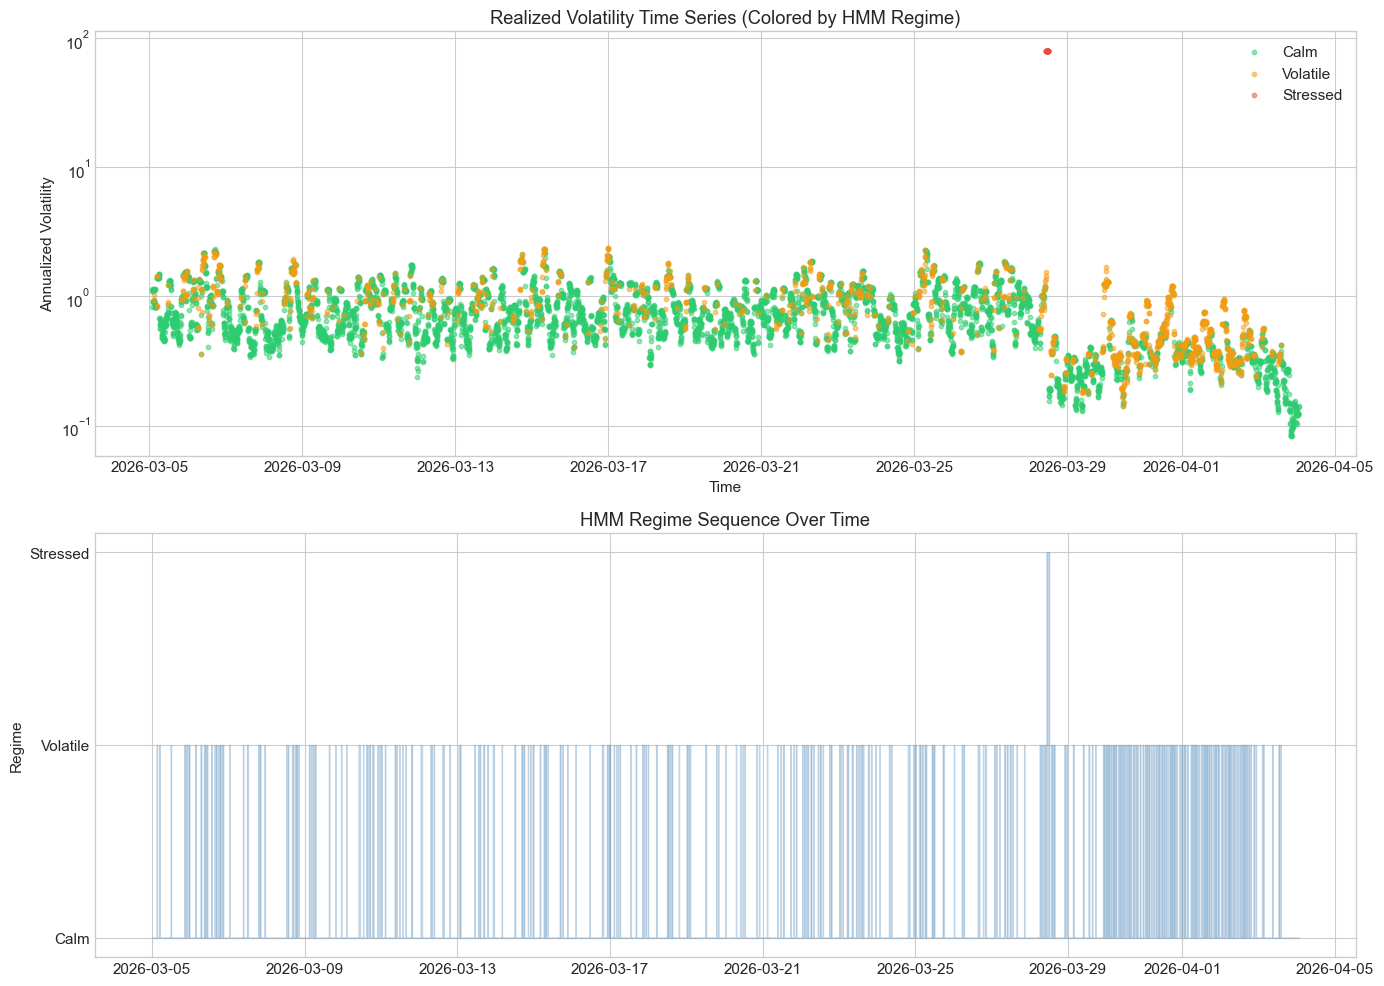

In [11]:
# Plot 1: Regime-colored volatility time series
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: Volatility time series colored by regime
ax1 = axes[0]

# Get price data with returns
price_df_indexed = price_df.set_index('timestamp')
returns = np.log(price_df_indexed['close'] / price_df_indexed['close'].shift(1))
vol_ts = returns.rolling(20).std() * np.sqrt(288 * 365)  # Annualized

# Align regime labels
common_idx = vol_ts.dropna().index.intersection(regime_labels.index)
vol_aligned = vol_ts.loc[common_idx]
regime_aligned = regime_labels.loc[common_idx]

# Color by regime
for regime in REGIME_ORDER:
    mask = regime_aligned == regime
    ax1.scatter(vol_aligned.index[mask], vol_aligned.values[mask],
                c=REGIME_COLORS[regime], label=regime, alpha=0.5, s=10)

ax1.set_xlabel('Time')
ax1.set_ylabel('Annualized Volatility')
ax1.set_title('Realized Volatility Time Series (Colored by HMM Regime)')
ax1.legend(loc='upper right')
ax1.set_yscale('log')

# Bottom: Regime distribution over time
ax2 = axes[1]
regime_numeric = regime_labels.map({'Calm': 0, 'Volatile': 1, 'Stressed': 2})
ax2.fill_between(regime_numeric.index, regime_numeric.values, step='post',
                 color='steelblue', alpha=0.3)
ax2.set_ylabel('Regime')
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(['Calm', 'Volatile', 'Stressed'])
ax2.set_title('HMM Regime Sequence Over Time')

plt.tight_layout()
plt.savefig(AS_COST_DIR / 'volatility_by_regime.png', dpi=150, bbox_inches='tight')
plt.show()

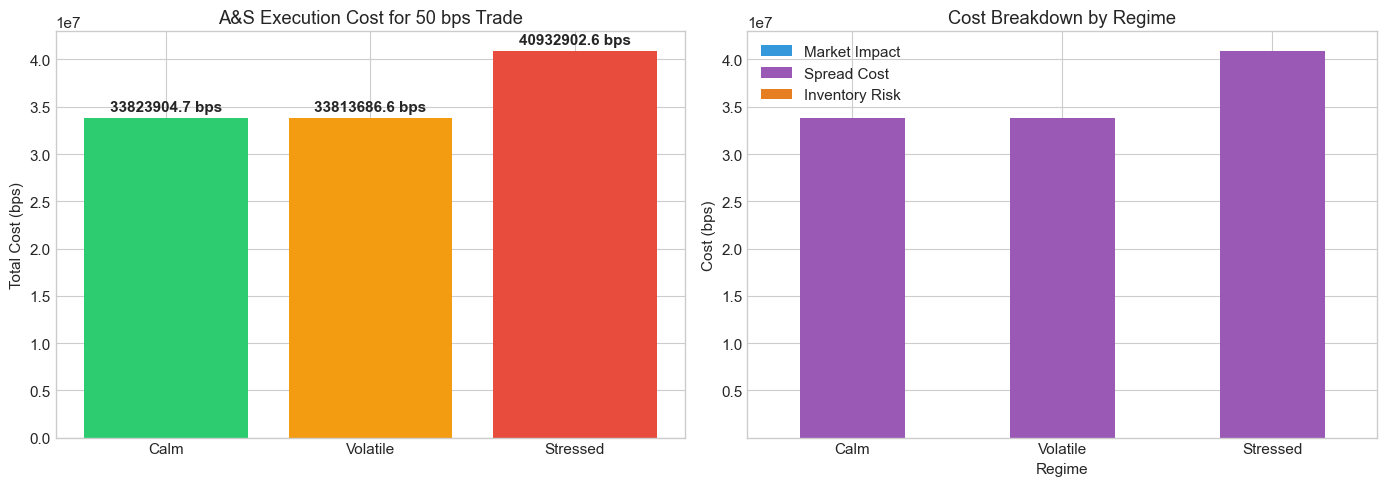

In [12]:
# Plot 2: Cost comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Total cost by regime
ax1 = axes[0]
cost_summary_df_sorted = cost_summary_df.reindex(REGIME_ORDER)
bars = ax1.bar(cost_summary_df_sorted.index, cost_summary_df_sorted['Total Cost (bps)'],
               color=[REGIME_COLORS[r] for r in REGIME_ORDER])
ax1.set_ylabel('Total Cost (bps)')
ax1.set_title(f'A&S Execution Cost for {TRADE_SIZE_BPS * 10000:.0f} bps Trade')
for bar, regime in zip(bars, REGIME_ORDER):
    height = bar.get_height()
    ax1.annotate(f'{height:.1f} bps',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontweight='bold')

# Right: Cost breakdown stacked bar
ax2 = axes[1]
cost_components = cost_summary_df_sorted[['Market Impact (bps)', 'Spread Cost (bps)', 'Inventory Risk (bps)']]
cost_components.plot(kind='bar', stacked=True, ax=ax2,
                     color=['#3498db', '#9b59b6', '#e67e22'])
ax2.set_ylabel('Cost (bps)')
ax2.set_title('Cost Breakdown by Regime')
ax2.legend(['Market Impact', 'Spread Cost', 'Inventory Risk'], loc='upper left')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(AS_COST_DIR / 'cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

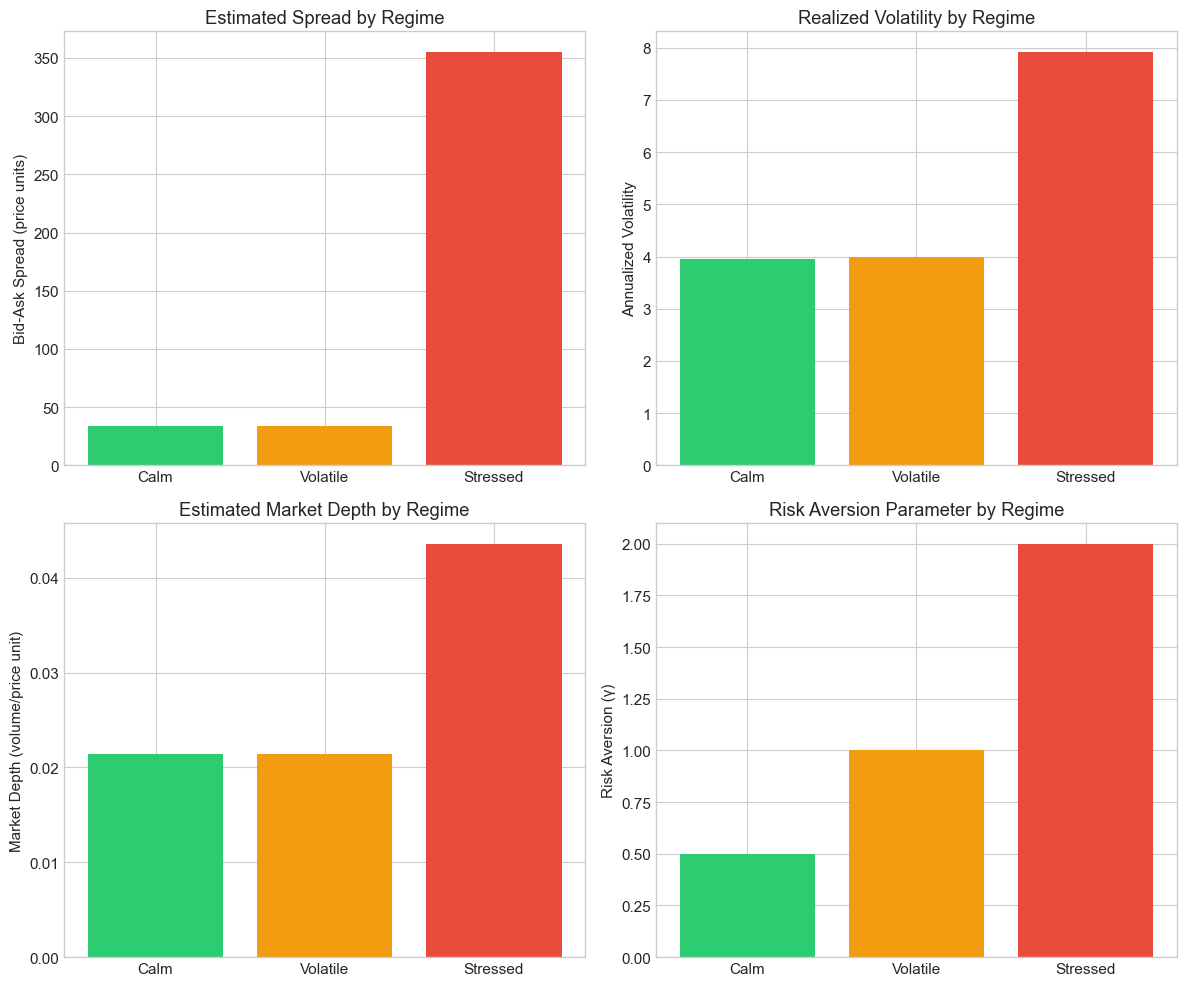

In [13]:
# Plot 3: Parameter comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Spread by regime
ax1 = axes[0, 0]
spreads = [results[r]['spread'] for r in REGIME_ORDER if r in results]
ax1.bar(REGIME_ORDER, spreads, color=[REGIME_COLORS[r] for r in REGIME_ORDER])
ax1.set_ylabel('Bid-Ask Spread (price units)')
ax1.set_title('Estimated Spread by Regime')

# Volatility by regime
ax2 = axes[0, 1]
vols = [results[r]['volatility'] for r in REGIME_ORDER if r in results]
ax2.bar(REGIME_ORDER, vols, color=[REGIME_COLORS[r] for r in REGIME_ORDER])
ax2.set_ylabel('Annualized Volatility')
ax2.set_title('Realized Volatility by Regime')

# Depth by regime
ax3 = axes[1, 0]
depths = [results[r]['depth'] for r in REGIME_ORDER if r in results]
ax3.bar(REGIME_ORDER, depths, color=[REGIME_COLORS[r] for r in REGIME_ORDER])
ax3.set_ylabel('Market Depth (volume/price unit)')
ax3.set_title('Estimated Market Depth by Regime')

# Gamma by regime
ax4 = axes[1, 1]
gammas = [results[r]['gamma'] for r in REGIME_ORDER if r in results]
ax4.bar(REGIME_ORDER, gammas, color=[REGIME_COLORS[r] for r in REGIME_ORDER])
ax4.set_ylabel('Risk Aversion (γ)')
ax4.set_title('Risk Aversion Parameter by Regime')

plt.tight_layout()
plt.savefig(AS_COST_DIR / 'parameter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary Statistics

In [14]:
# Final summary
print("\n" + "="*60)
print("LAYER 2: A&S PER-REGIME COST CALIBRATION - SUMMARY")
print("="*60)

print("\n### Calibrated Parameters ###")
for regime in REGIME_ORDER:
    if regime in results:
        p = results[regime]
        print(f"\n{regime}:")
        print(f"  Trades: {p['n_trades']:,}")
        print(f"  Price bars: {p['n_price_bars']:,}")
        print(f"  Spread: {p['spread']:.6f}")
        print(f"  Volatility: {p['volatility']:.4f} (annualized)")
        print(f"  Depth: {p['depth']:.2f}")
        print(f"  Gamma: {p['gamma']}")

print("\n### Cost for 50 bps Trade ###")
print(cost_summary_df.round(2).to_string())

print("\n### Validation ###")
print(f"Stressed/Calm cost ratio: {validation['ratios'].get('stressed_to_calm', 'N/A'):.1f}x")
print(f"Expected range: [10, 100]")
print(f"Status: {'PASSED' if validation['passed'] else 'FAILED'}")

print("\n### Output Files ###")
for f in AS_COST_DIR.glob('*'):
    print(f"  {f.name}")


LAYER 2: A&S PER-REGIME COST CALIBRATION - SUMMARY

### Calibrated Parameters ###

Calm:
  Trades: 8,656
  Price bars: 8,656
  Spread: 33.814963
  Volatility: 3.9596 (annualized)
  Depth: 0.02
  Gamma: 0.5

Volatile:
  Trades: 8,484
  Price bars: 8,484
  Spread: 33.804082
  Volatility: 3.9990 (annualized)
  Depth: 0.02
  Gamma: 1.0

Stressed:
  Trades: 20
  Price bars: 20
  Spread: 355.057115
  Volatility: 7.9192 (annualized)
  Depth: 0.04
  Gamma: 2.0

### Cost for 50 bps Trade ###
          Total Cost (bps)  Market Impact (bps)  Spread Cost (bps)  Inventory Risk (bps)
Regime                                                                                  
Calm           33823904.70              8356.15        33814963.35                585.20
Volatile       33813686.63              8435.69        33804081.57               1169.37
Stressed       40932902.57               214.92        40931540.18               1147.47

### Validation ###
Stressed/Calm cost ratio: 10.5x
Expected range